# Feature Selection with Wrapper Based Methods

Unlike filter based methods which are independent of the model, wrapper methods use the model's performance to decide feature importance. Now, we will use Recursive Feature Elimination (RFE) to iteratively remove the last useful features, and its CV implementation, RFECV to choose the optimal number of features using cross-validation.

In [1]:
import pandas as pd, numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE, RFECV
from sklearn.pipeline import Pipeline

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


We have 8 numerical features describing housing and demographics. 

#### Data Splitting and Scaling

Linear regression models are sensitive to feature scale, so we need to scale the features here.

In [4]:
# Features and Target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((16512, 8), (16512,), (4128, 8), (4128,))

In [5]:
# Scale only on training data to avoid leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, y_train.shape, X_test_scaled.shape, y_test.shape

((16512, 8), (16512,), (4128, 8), (4128,))

### Building a Regression Model

#### RFE

Let's use Recursive Feature Elimination (RFE) to observe performance changes as we vary the number of features

In [6]:
# Model for RFE
model = LinearRegression()

Let's now perform RFE on different values of k and test the performance for each

In [7]:
k_values = [1,2,3,4,5,6,7,8]

rfe_scores = {}

for k in k_values:

    selector = RFE(estimator=model, n_features_to_select=k, step=1)
    selector.fit(X_train_scaled, y_train)

    # reduced columns
    X_train_sel = selector.transform(X_train_scaled)
    X_test_sel = selector.transform(X_test_scaled)


    model.fit(X_train_sel, y_train)
    preds = model.predict(X_test_sel)

    rmse = math.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    rfe_scores[k] = (rmse, r2)

print("{'k' : 'rmse', 'r2'}")
rfe_scores

{'k' : 'rmse', 'r2'}


{1: (1.1310274666339697, 0.024752565317272213),
 2: (1.0023006777637837, 0.23411324125903388),
 3: (0.7432554224606601, 0.5788423577638913),
 4: (0.7416696901899971, 0.5806375168001885),
 5: (0.7353455604777588, 0.5877587344849997),
 6: (0.7283238726208252, 0.5955939876892117),
 7: (0.7274399891247547, 0.5965749548568096),
 8: (0.727420259918385, 0.5965968374812354)}

Let us see how predictive error (RMSE) and explained variance (R²) change as we vary the number of selected features.

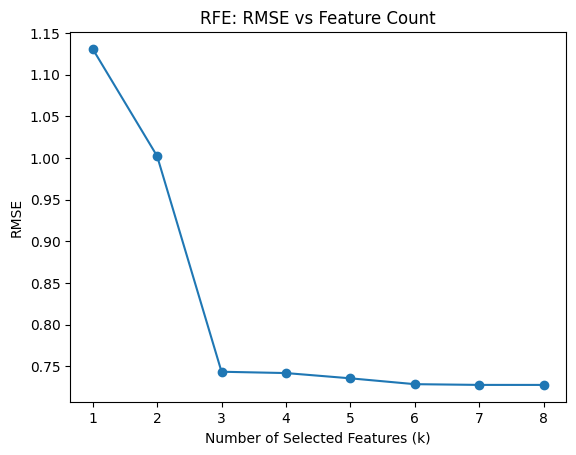

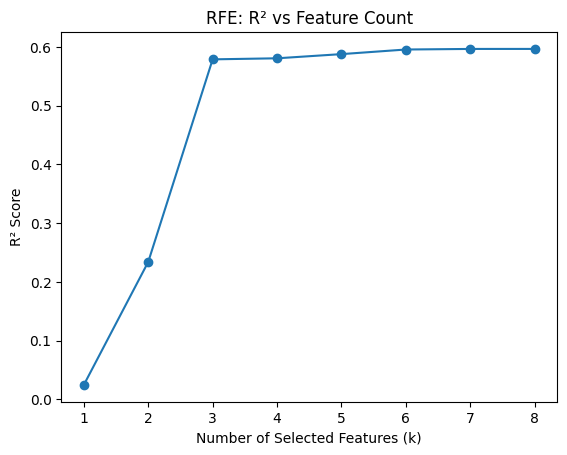

In [8]:
rmse_list = [rfe_scores[k][0] for k in k_values]
r2_list = [rfe_scores[k][1] for k in k_values]

scores_df = pd.DataFrame(rfe_scores).T.reset_index()
scores_df.rename(columns={"index": "k", 0: "rmse", 1: "r2"}, inplace=True)

# RMSE
fig1, ax1 = plt.subplots()
ax1.plot(scores_df["k"], scores_df["rmse"], marker='o')
ax1.set_xlabel("Number of Selected Features (k)")
ax1.set_ylabel("RMSE")
ax1.set_title("RFE: RMSE vs Feature Count")

# R2
fig2, ax2 = plt.subplots()
ax2.plot(scores_df["k"], scores_df["r2"], marker='o')
ax2.set_xlabel("Number of Selected Features (k)")
ax2.set_ylabel("R² Score")
ax2.set_title("RFE: R² vs Feature Count")

plt.show()

These results show how the model behaves as we allow more features to remain.

Although RFE reported its best score when retaining 8 features, the improvement over 3-4 features is marginal. Keeping slightly fewer features gives us a simpler model with very similar (almost indistinguishable) generalisation performance.

In practice:

- 3-4 features: better complexity–accuracy trade-off  
- 8 features: slight gain in score, but more risk of noise and overfitting

> If the performance difference is very small, we prefer the simpler model


Let's check the selected feature names

In [9]:
best_k = 4

selector_best = RFE(estimator=model, n_features_to_select=best_k)
selector_best.fit(X_train_scaled, y_train)

selected_features = np.array(feature_names)[selector_best.support_]
pd.DataFrame({"Selected Features": selected_features})

,Selected Features
0,MedInc
1,AveBedrms
2,Latitude
3,Longitude


The preferred feature count is where RMSE is lowest and R² highest. Our function checks for this strictly, but very small improvements for including all the features might not be the tradeoff we always go for, so we choose 4 here.

A flat curve suggests that increasing the number of features over a range does is not adding any particular contribution. 


Now, let's use cross validation and `RFECV` to perform feature selection.

#### RFECV

RFECV identifies the number of features that give the best cross-validated generalisation performance.

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)

rfecv = RFECV(estimator=LinearRegression(), step=1, 
              cv=cv, scoring='neg_mean_squared_error')

rfecv.fit(X_train_scaled, y_train)

best_k = rfecv.n_features_
best_k

np.int64(3)

RFECV picked 3 features as it found further features to not benefit the linear estimator enough during cross-validation, so a small core set of strong linear predictors becomes optimal for generalisation.

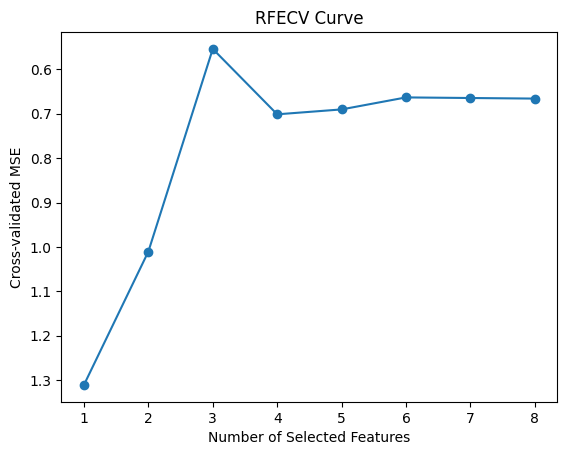

In [11]:
# Extract cross-validated negative MSE scores
mean_scores = rfecv.cv_results_["mean_test_score"]

# Convert to positive MSE for better visualisation
mse_scores = -mean_scores

plt.plot(range(1, len(mse_scores) + 1), mse_scores, marker='o')
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-validated MSE")
plt.title("RFECV Curve")
plt.gca().invert_yaxis()
plt.show()

RFECV determines how many features should be kept to achieve the best cross-validated performance.

In [14]:
# we can also check the selected featues

selected_features = np.array(feature_names)[rfecv.support_]
selected_features

array(['MedInc', 'Latitude', 'Longitude'], dtype='<U10')

In [13]:
# taking selected feature sets from training
X_train_final = X_train_scaled[:, rfecv.support_]
X_test_final = X_test_scaled[:, rfecv.support_]

model_final = LinearRegression()
model_final.fit(X_train_final, y_train)

preds_test = model_final.predict(X_test_final)  # test using testing set as we performed kfold cv

rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
r2_test = r2_score(y_test, preds_test)

rmse_test, r2_test

(np.float64(0.7432554224606601), 0.5788423577638913)

Wrapper-based feature selection provides a way to identify and keep only the predictors that help model performance.

A balanced decision can be taken by considering:
- generalisation performance (RMSE and R²)
- model stability under cross-validation
- complexity vs interpretability